### **Data Understanding ✓**

El **objetivo** de esta sección es explorar los datos contenidos en final_dataset.csv, a fin de identificar la columna target (columna `occured`) para poder ralizar la separación entre train y test.

In [10]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.data_utils import guardar_dataset, plot_distribuciones, plot_distribuciones_por_clase, plot_correlacion, plot_boxplots

In [12]:
fire_df = pd.read_csv("../data_sample/final_dataset.csv")

# Comprobamos que los datos se han cargado correctamente
fire_df.head()

,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,occured,frp
0,0.0,-15.19928,38.54393,5.654271,955.608333,136.083333,43.611845,250.333333,15.883333,18.375000,4.89,35.0,23.175000,12.9,13.5,0.0,3.69
1,1.0,31.51203,-101.57546,16.564673,927.016667,181.333333,31.925260,296.916667,10.529167,3.416667,7.24,16.0,29.733333,13.4,16.2,0.0,0.73
2,1.0,-13.74538,28.05493,5.542089,884.379167,109.166667,8.379870,210.958333,6.095833,12.208333,3.68,35.0,14.104167,11.1,16.8,0.0,0.78
3,0.0,13.53091,-11.22573,7.703410,981.158333,168.416667,133.287570,244.208333,13.095833,56.458333,5.59,29.0,26.704167,12.9,11.0,0.0,8.91
4,0.0,5.61833,16.59892,16.895093,917.116667,202.208333,91.791875,266.750000,6.712500,9.166667,6.00,10.0,26.820833,16.0,16.6,0.0,5.97


In [13]:
# Exploramos el contenido de los datos
fire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118858 entries, 0 to 118857
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   daynight_N                118858 non-null  float64
 1   lat                       118858 non-null  float64
 2   lon                       118858 non-null  float64
 3   fire_weather_index        118858 non-null  float64
 4   pressure_mean             118858 non-null  float64
 5   wind_direction_mean       118858 non-null  float64
 6   wind_direction_std        118858 non-null  float64
 7   solar_radiation_mean      118858 non-null  float64
 8   dewpoint_mean             118858 non-null  float64
 9   cloud_cover_mean          118858 non-null  float64
 10  evapotranspiration_total  118858 non-null  float64
 11  humidity_min              118858 non-null  float64
 12  temp_mean                 118858 non-null  float64
 13  temp_range                118858 non-null  float64
 14 

In [14]:
data_dict = pd.DataFrame({
    'columna': fire_df.columns,
    'dtype': fire_df.dtypes.values,
    'nulos_pct': (fire_df.isnull().mean() * 100).round(1).values,
    'unicos': fire_df.nunique().values,
    'ejemplo': [fire_df[c].dropna().iloc[0] if len(fire_df[c].dropna()) > 0 else None for c in fire_df.columns]
})
data_dict

,columna,dtype,nulos_pct,unicos,ejemplo
0,daynight_N,float64,0.0,2,0.000000
1,lat,float64,0.0,117561,-15.199280
2,lon,float64,0.0,118094,38.543930
3,fire_weather_index,float64,0.0,115108,5.654271
4,pressure_mean,float64,0.0,48551,955.608333
5,wind_direction_mean,float64,0.0,7612,136.083333
6,wind_direction_std,float64,0.0,98239,43.611845
7,solar_radiation_mean,float64,0.0,6240,250.333333
8,dewpoint_mean,float64,0.0,14199,15.883333
9,cloud_cover_mean,float64,0.0,2401,18.375000


La variable target sería `occured`, siendo cero la no existencia de fuego y 1 la detección de fuego. También vemos que hay otra variable categórica con dos niveles, `daynight_N`. 

Pasamos a realizar la división entre train y test, previa comprobación de si algún nivel de la variable target está infrarrepresentado.

<Axes: xlabel='occured', ylabel='count'>

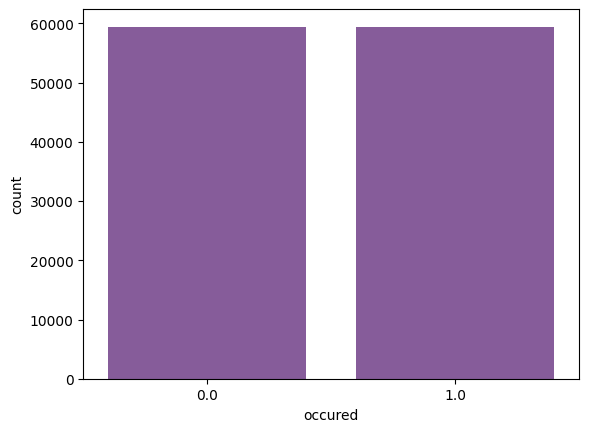

In [15]:
sns.countplot(data=fire_df, x='occured', color=plt.cm.BuPu(0.7))

In [16]:
# Definimos las columnas de features:
columnas = fire_df.columns.tolist()
X = fire_df.drop(columns=["occured"])

# La columna Target:
y = fire_df['occured']

# Y realizamos la división en dos datasets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Guardamos los nuevos dataframes:

guardar_dataset(X_train, "train_raw")
guardar_dataset(X_test, "test_raw")

Dataset guardado en: src/data_sample\train_raw.csv (95086 filas, 16 columnas)
Dataset guardado en: src/data_sample\test_raw.csv (23772 filas, 16 columnas)


'src/data_sample\\test_raw.csv'

**Conclusiones**

- La variable target está equilibrada entre los dos niveles (que ya están codificadas)
- Contamos solo con la presencia de una variable categórica ya preocesada en niveles numéricos.
- El dataset no tiene datos nulos.
- El dataset cuenta con las siguientes features basadas en variables medioambientales:

| Variable | Descripción |
|---|---|
| `daynight_N` | Variable binaria que indica el momento del día. 0 = noche, 1 = día. |
| `latitude` | Coordenada de latitud del punto de observación. |
| `longitude` | Coordenada de longitud del punto de observación. |
| `FWI` (Fire Weather Index) | Índice numérico que representa una medida compuesta del riesgo de incendio en función de varios factores meteorológicos. |
| `pressure` | Presión atmosférica media durante el periodo de observación de 1 hora. |
| `wind_direction_avg` | Dirección media del viento, en grados, durante el periodo de 1 hora. |
| `wind_direction_std` | Desviación estándar de la dirección del viento durante el periodo de 1 hora, utilizada para evaluar su variabilidad. |
| `solar_radiation` | Radiación solar media recibida durante el periodo de observación de 1 hora. |
| `dewpoint` | Temperatura media del punto de rocío (medida de la humedad atmosférica) durante el periodo de 1 hora. |
| `cloud_cover` | Cobertura nubosa media, normalmente expresada en porcentaje o fracción, durante el periodo de 1 hora. |
| `evapotranspiration_total` | Cantidad total de agua transferida desde el suelo a la atmósfera por evaporación y transpiración de las plantas durante el periodo de 1 hora. |
| `humidity_min` | Humedad mínima registrada durante el periodo de observación de 1 hora. |
| `temperature_avg` | Temperatura media durante el periodo de 1 hora. |
| `temperature_range` | Diferencia entre la temperatura máxima y mínima registradas durante el periodo de observación de 1 hora. |
| `wind_speed_max` | Velocidad máxima del viento registrada durante el periodo de observación de 1 hora. |
| `occured` (target) | Variable objetivo binaria. 1 = se detectó un incendio, 0 = no se detectó. Variable adecuada para tareas de clasificación. |
| `frp` (Fire Radiative Power) | Valor numérico continuo que cuantifica la energía calorífica liberada por un incendio. Variable adecuada para tareas de regresión. |